In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "whitegrid")
warnings.filterwarnings("ignore")

In [3]:
# reading the data
df = pd.read_csv("../data/data.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
# shape
df.shape

(500, 9)

In [5]:
# size
df.size

4500

In [6]:
# concise summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [7]:
# statistical summary
df.describe(include = "all").T

,count,mean,std,min,25%,50%,75%,max
Serial No.,500.0,250.50000,144.481833,1.00,125.7500,250.50,375.25,500.00
GRE Score,500.0,316.47200,11.295148,290.00,308.0000,317.00,325.00,340.00
TOEFL Score,500.0,107.19200,6.081868,92.00,103.0000,107.00,112.00,120.00
University Rating,500.0,3.11400,1.143512,1.00,2.0000,3.00,4.00,5.00
SOP,500.0,3.37400,0.991004,1.00,2.5000,3.50,4.00,5.00
LOR,500.0,3.48400,0.925450,1.00,3.0000,3.50,4.00,5.00
CGPA,500.0,8.57644,0.604813,6.80,8.1275,8.56,9.04,9.92
Research,500.0,0.56000,0.496884,0.00,0.0000,1.00,1.00,1.00
Chance of Admit,500.0,0.72174,0.141140,0.34,0.6300,0.72,0.82,0.97


In [8]:
# dropping "Serial No."
df.drop(columns = "Serial No.", inplace = True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
# graphical analysis

In [10]:
numerical_features = df.select_dtypes(include = ["int", "float"]).columns.tolist()
numerical_features

['GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR ',
 'CGPA',
 'Research',
 'Chance of Admit ']

In [11]:
categorical_features = df.select_dtypes(include = ["object"]).columns.tolist()
categorical_features

[]

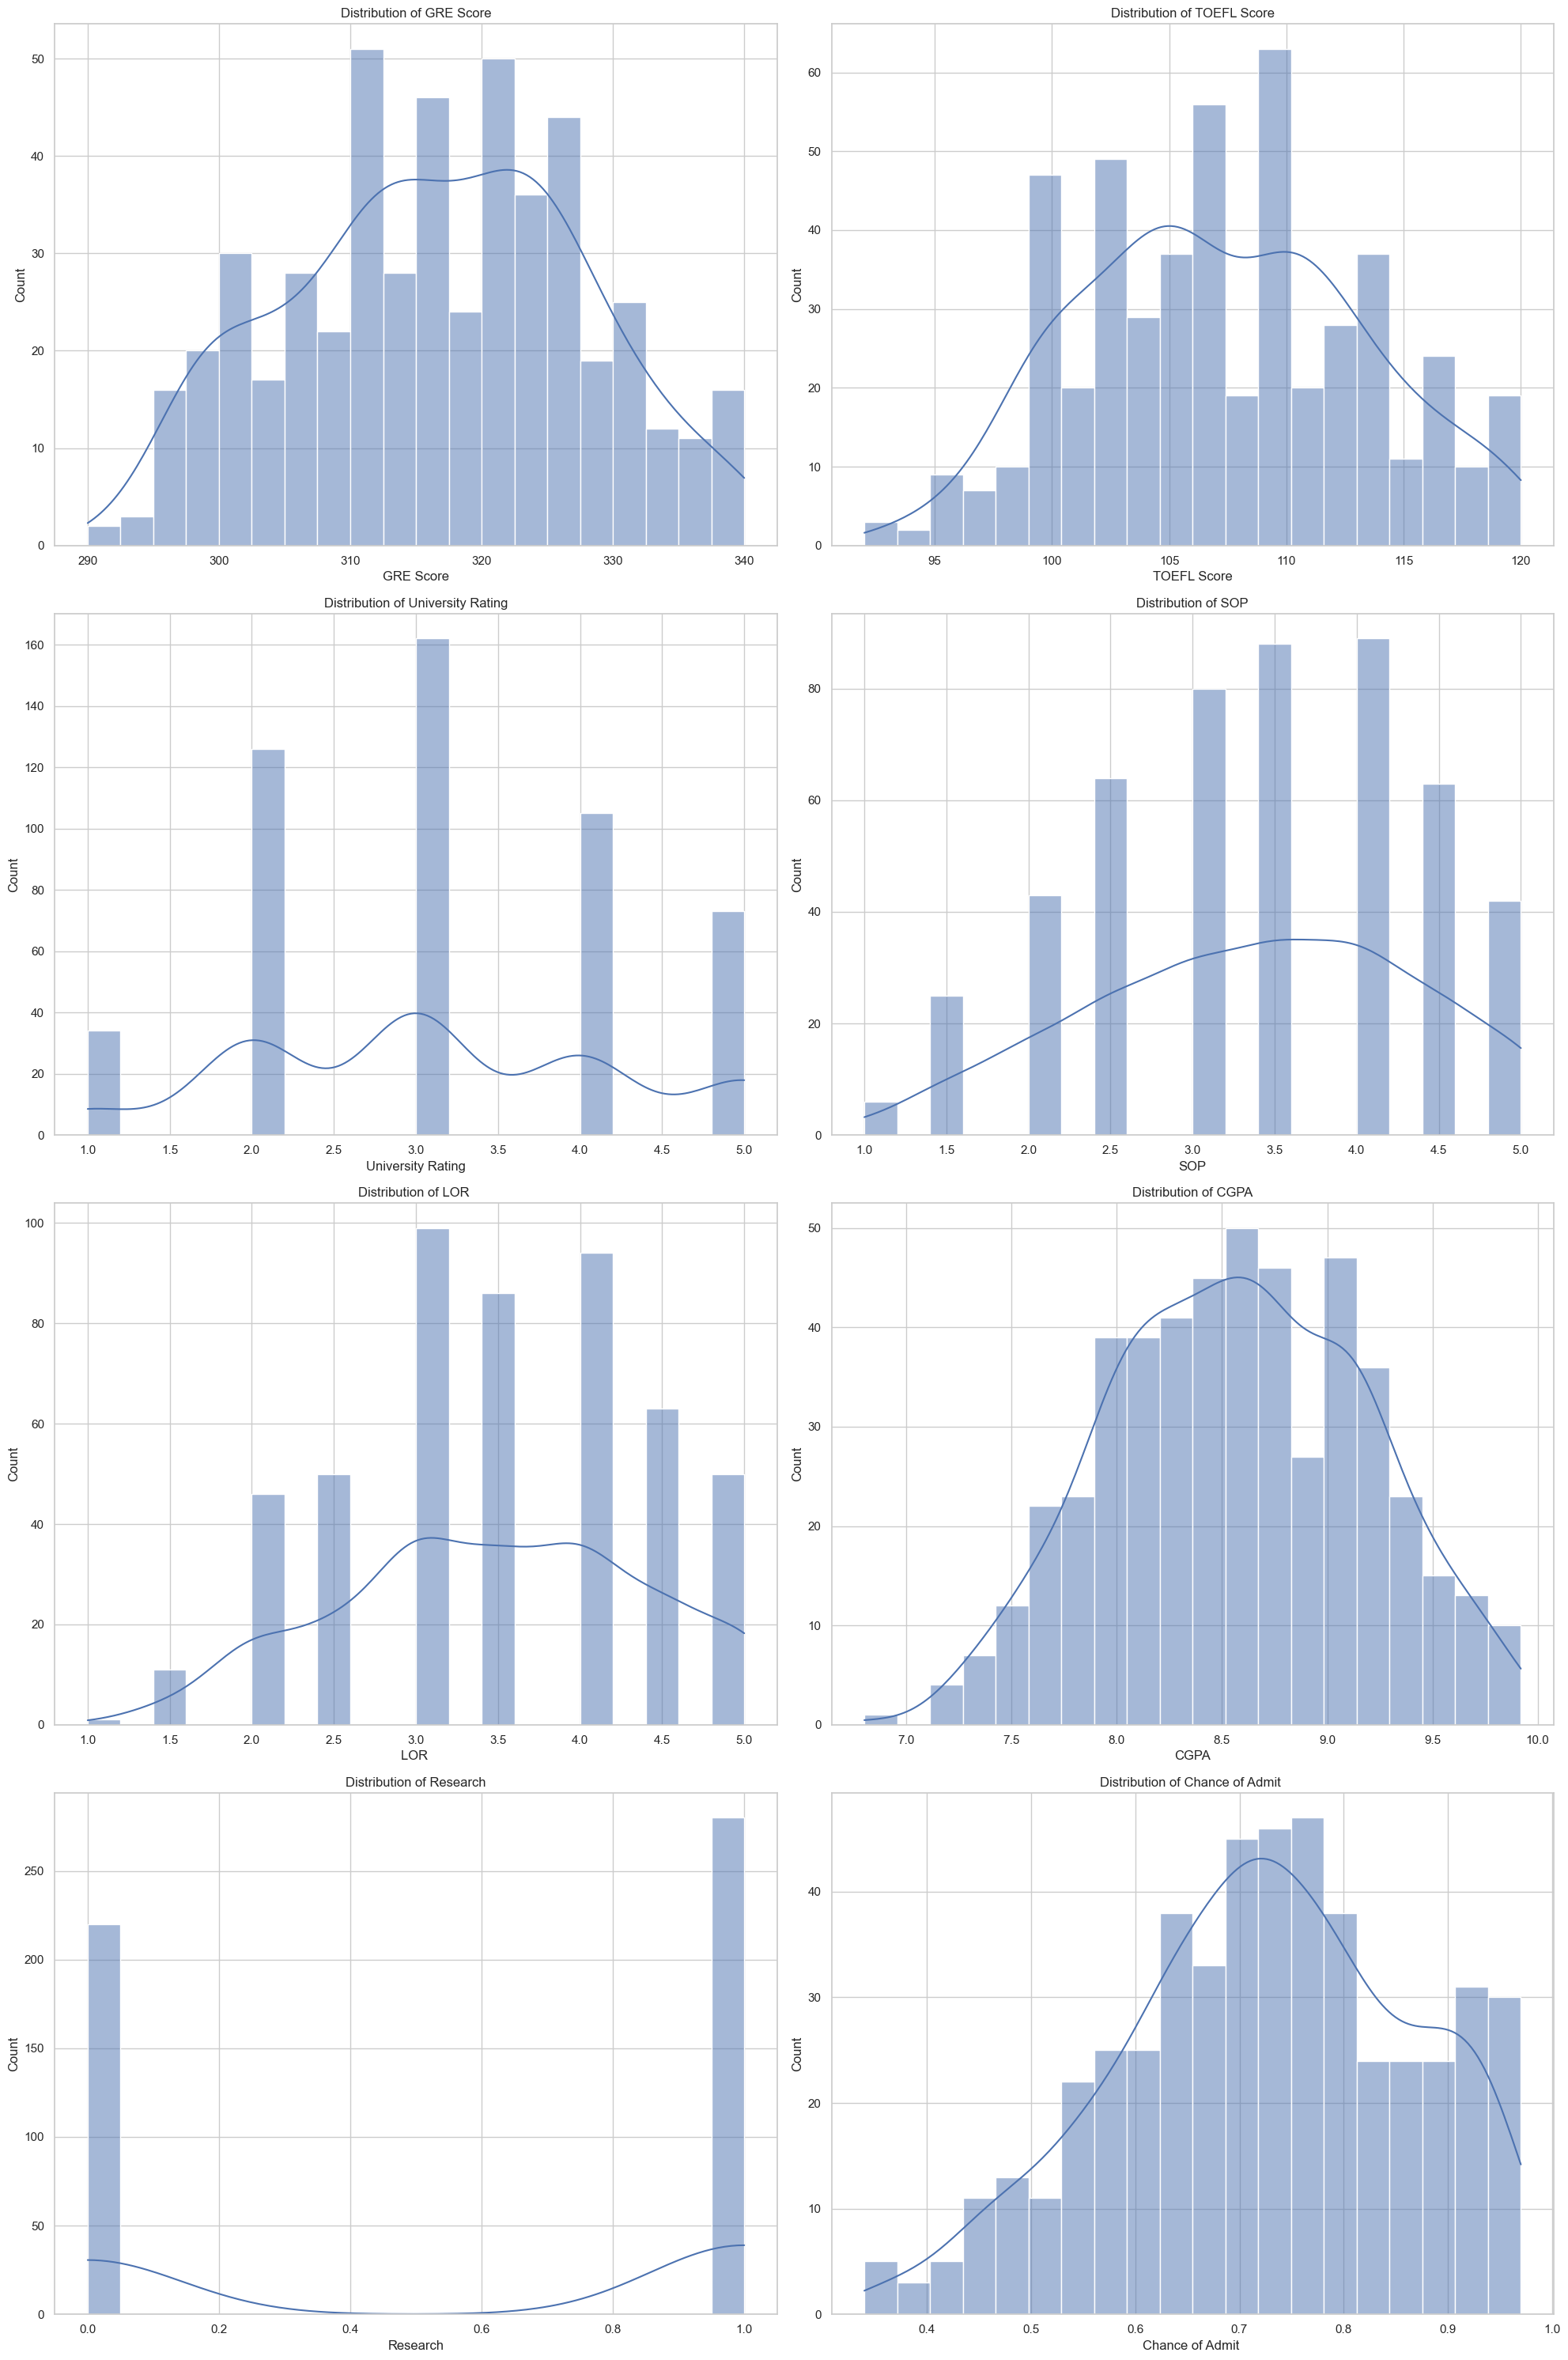

In [12]:
# ditribution of all numerical columns
plt.figure(figsize = (20, 30))
for i, column in enumerate(numerical_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[column], kde=True, bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../artifacts/distribution_plots_of_numerical_columns.png")
plt.show()

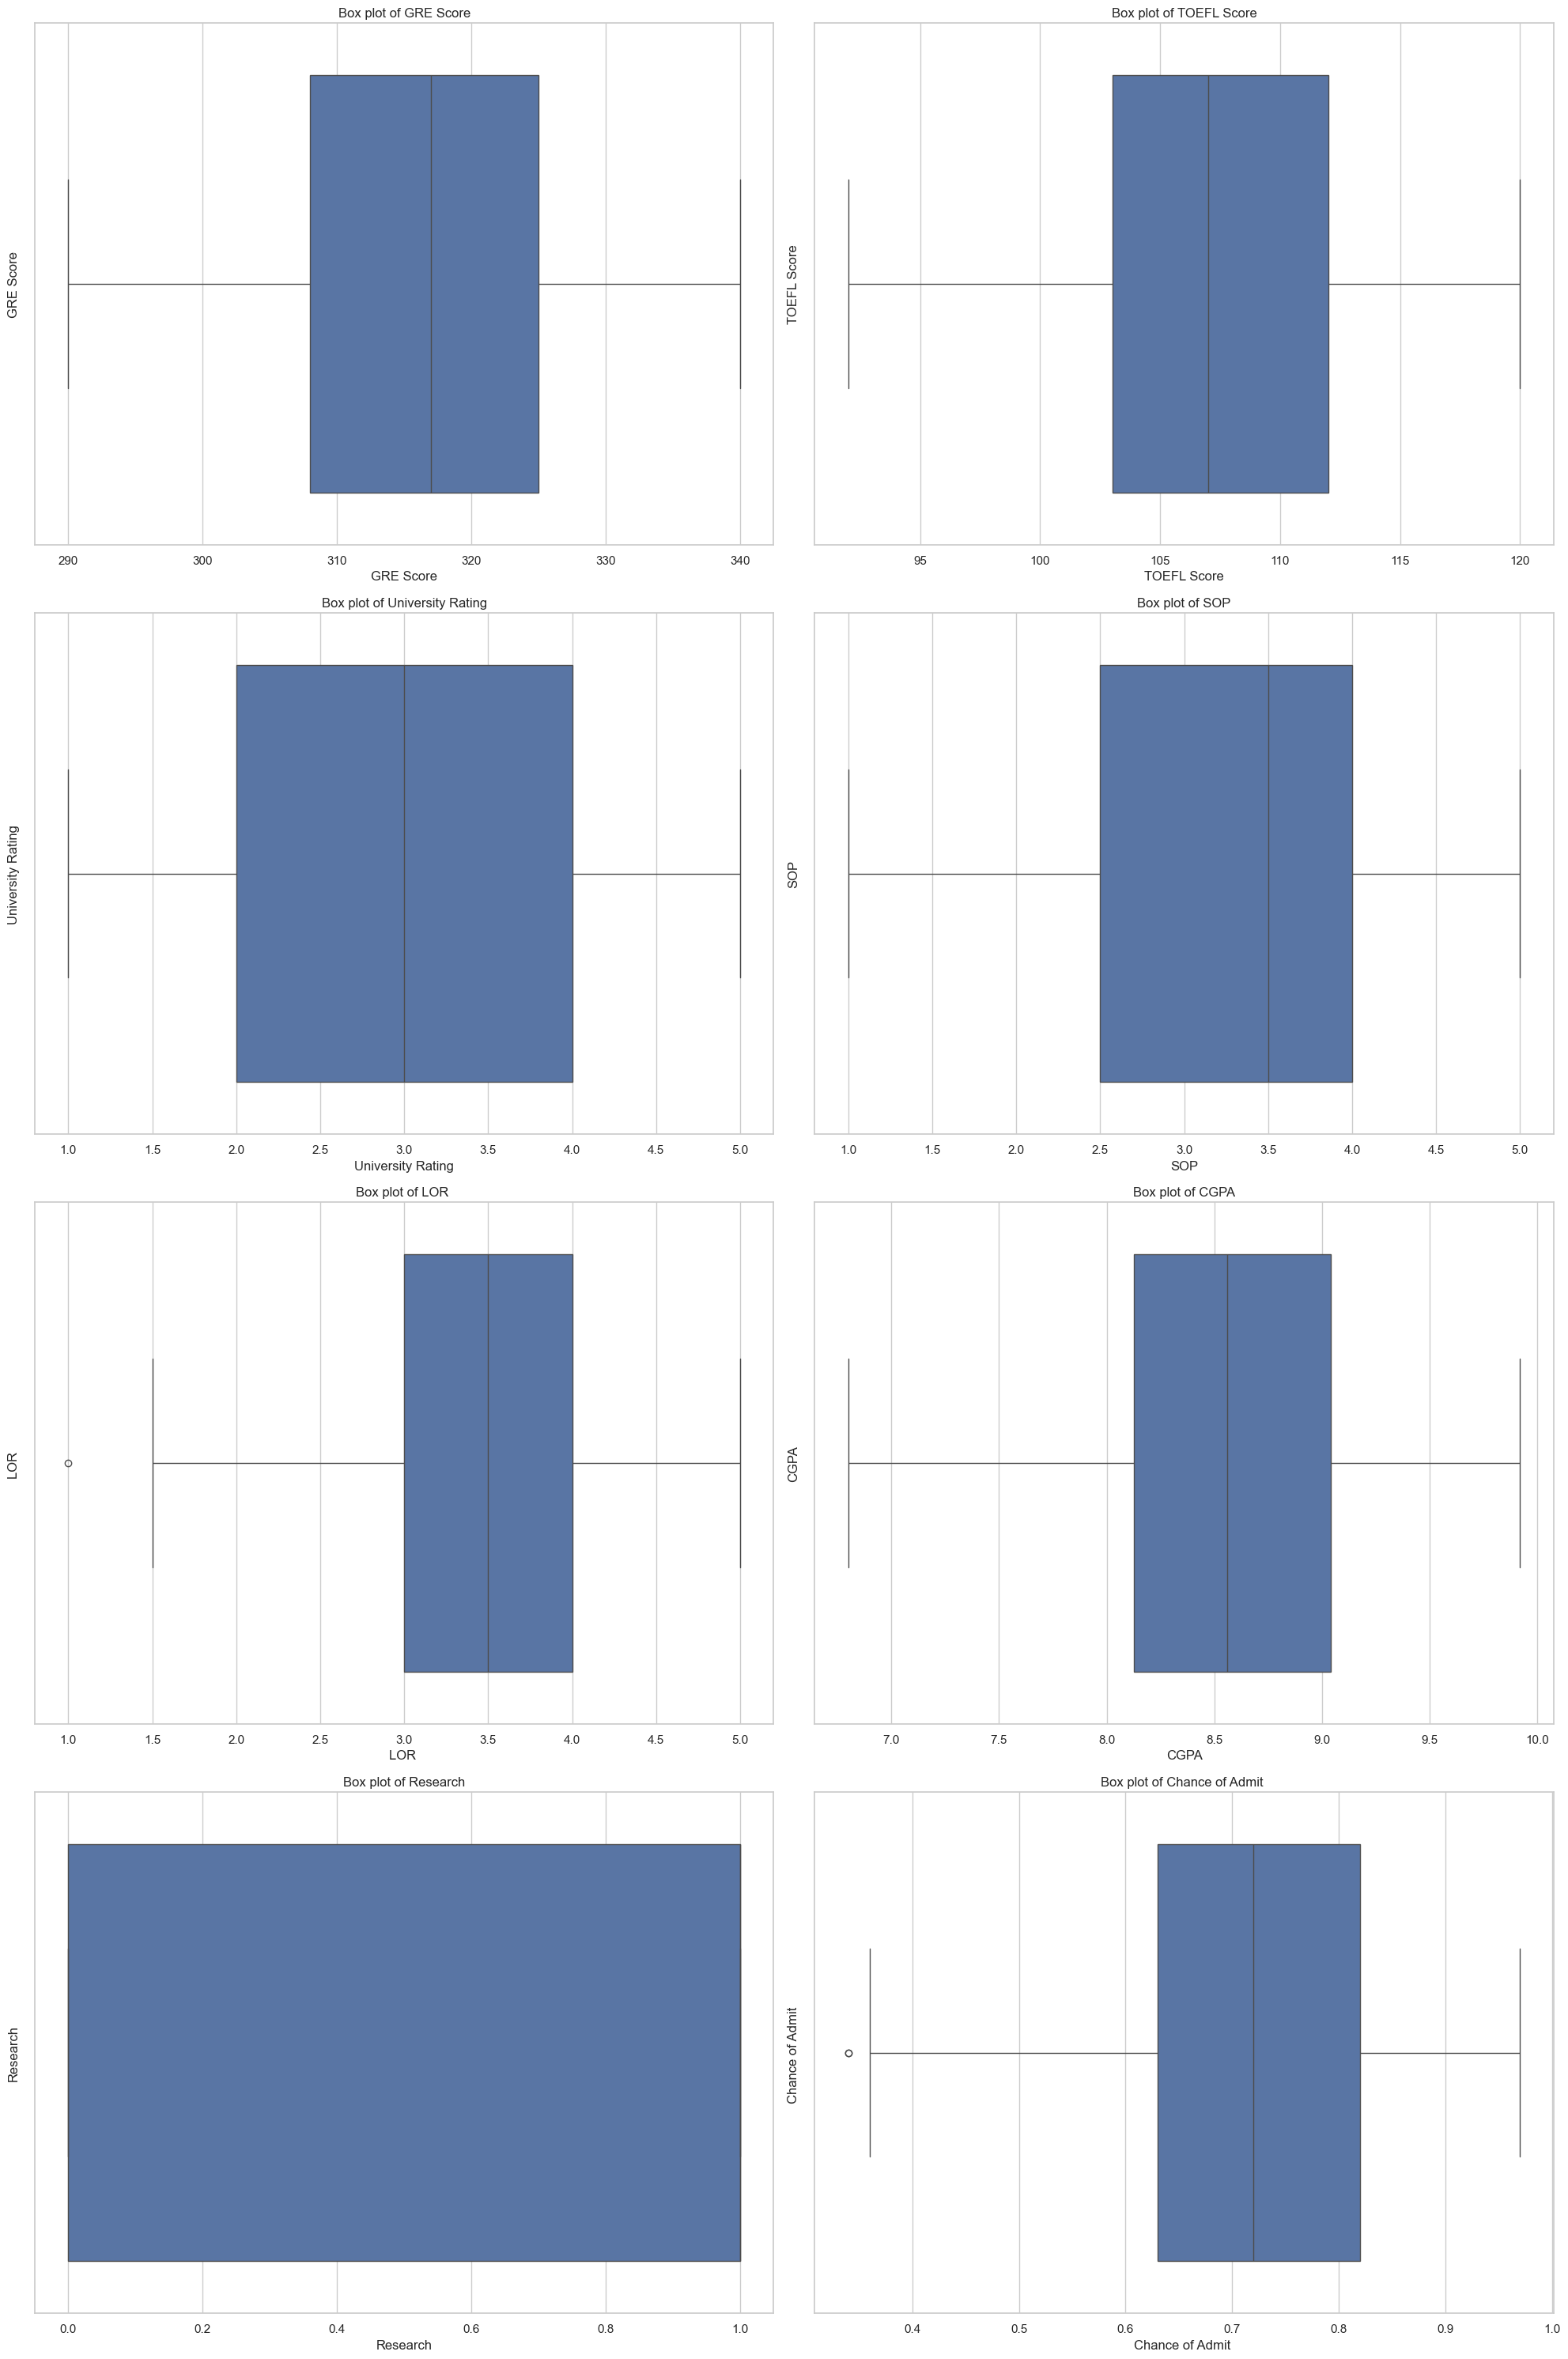

In [13]:
# box plot of all the numerical columns
plt.figure(figsize = (20, 30))
for i, column in enumerate(numerical_features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data = df, x = column)
    plt.title(f"Box plot of {column}")
    plt.ylabel(column)
plt.tight_layout()
plt.savefig("../artifacts/box_plots_of_numerical_columns.png")
plt.show()

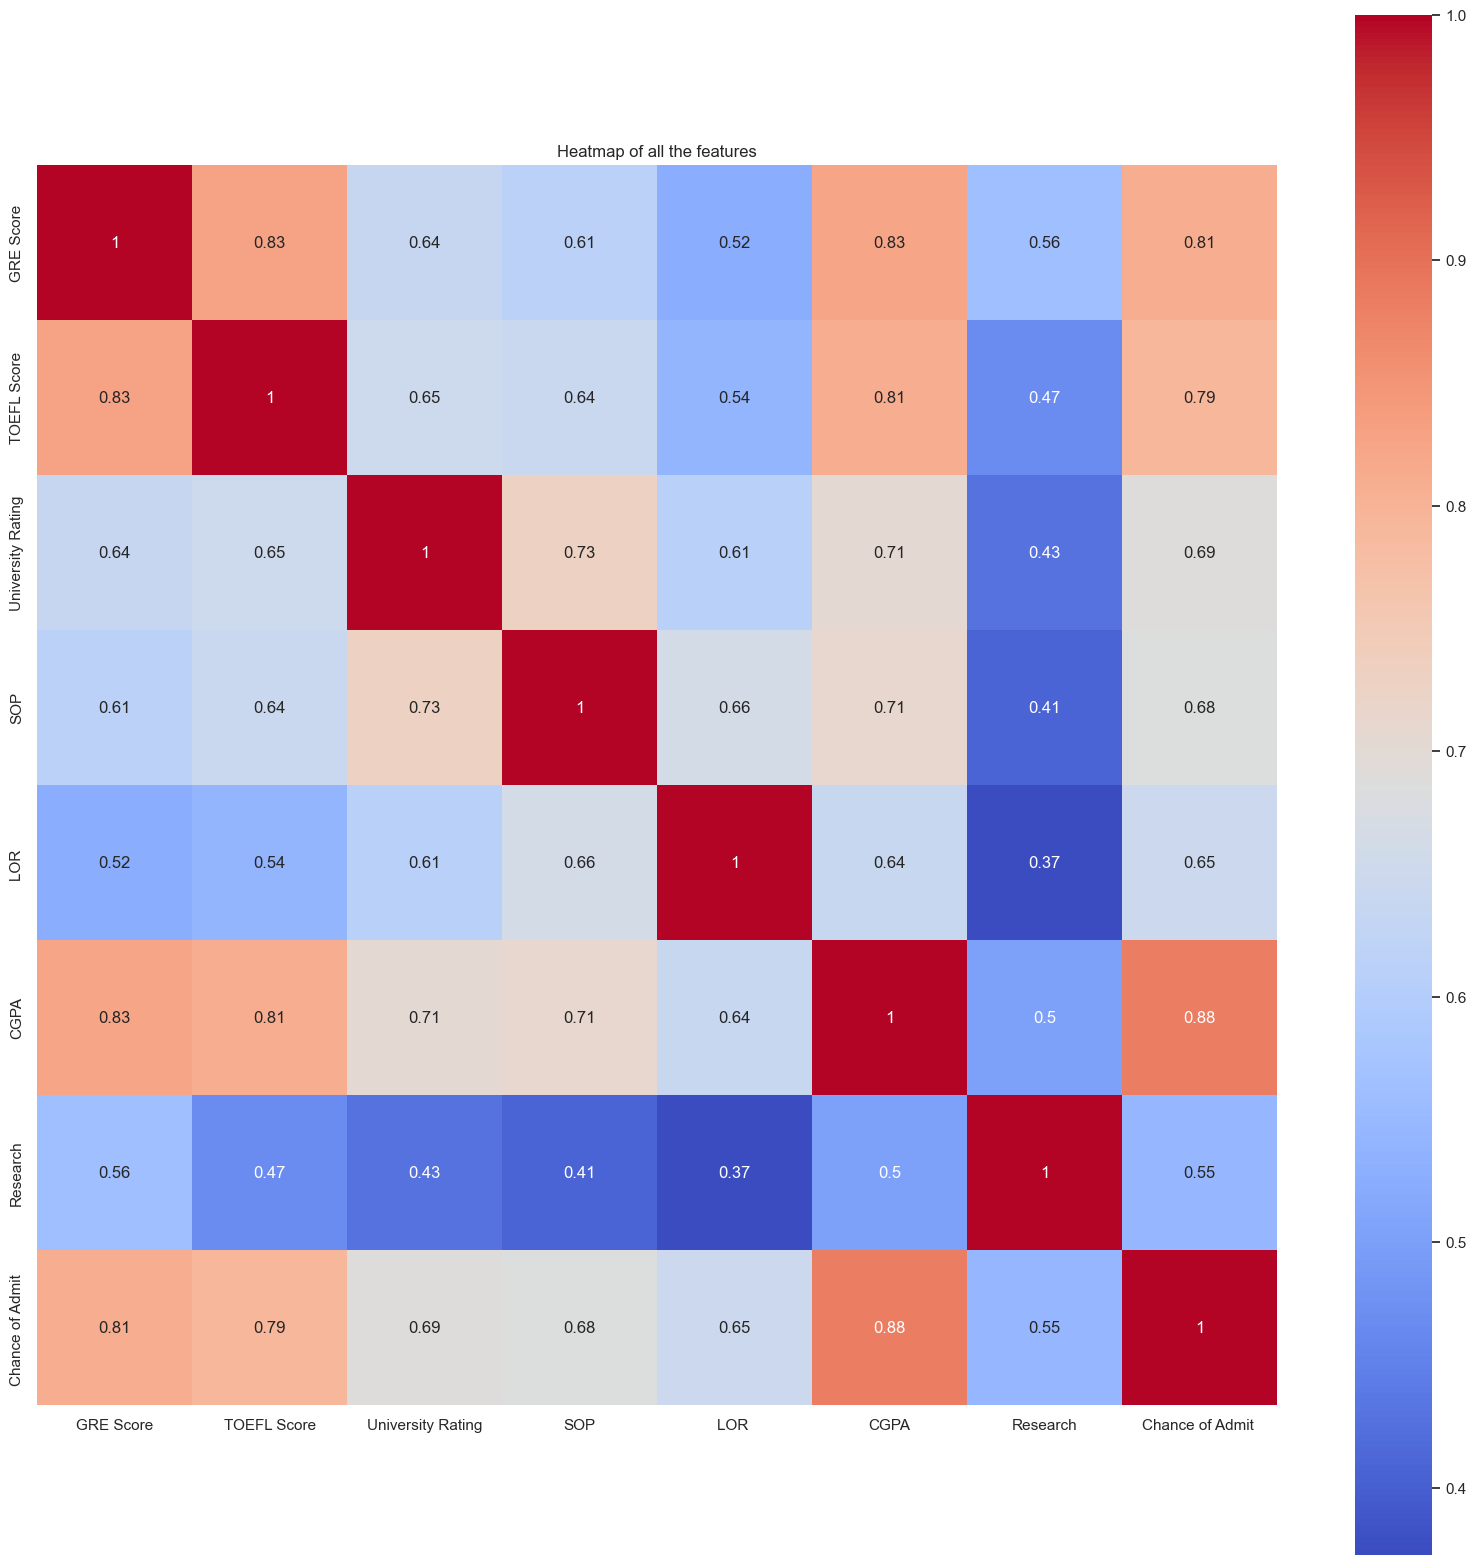

In [14]:
# correlation plot of numerical features
corr_matrix = df.corr()
plt.figure(figsize = (20, 20))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", square = True)
plt.title("Heatmap of all the features")
plt.savefig("../artifacts/heatmap_of_all_columns.png")
plt.show()

<Figure size 700x700 with 0 Axes>

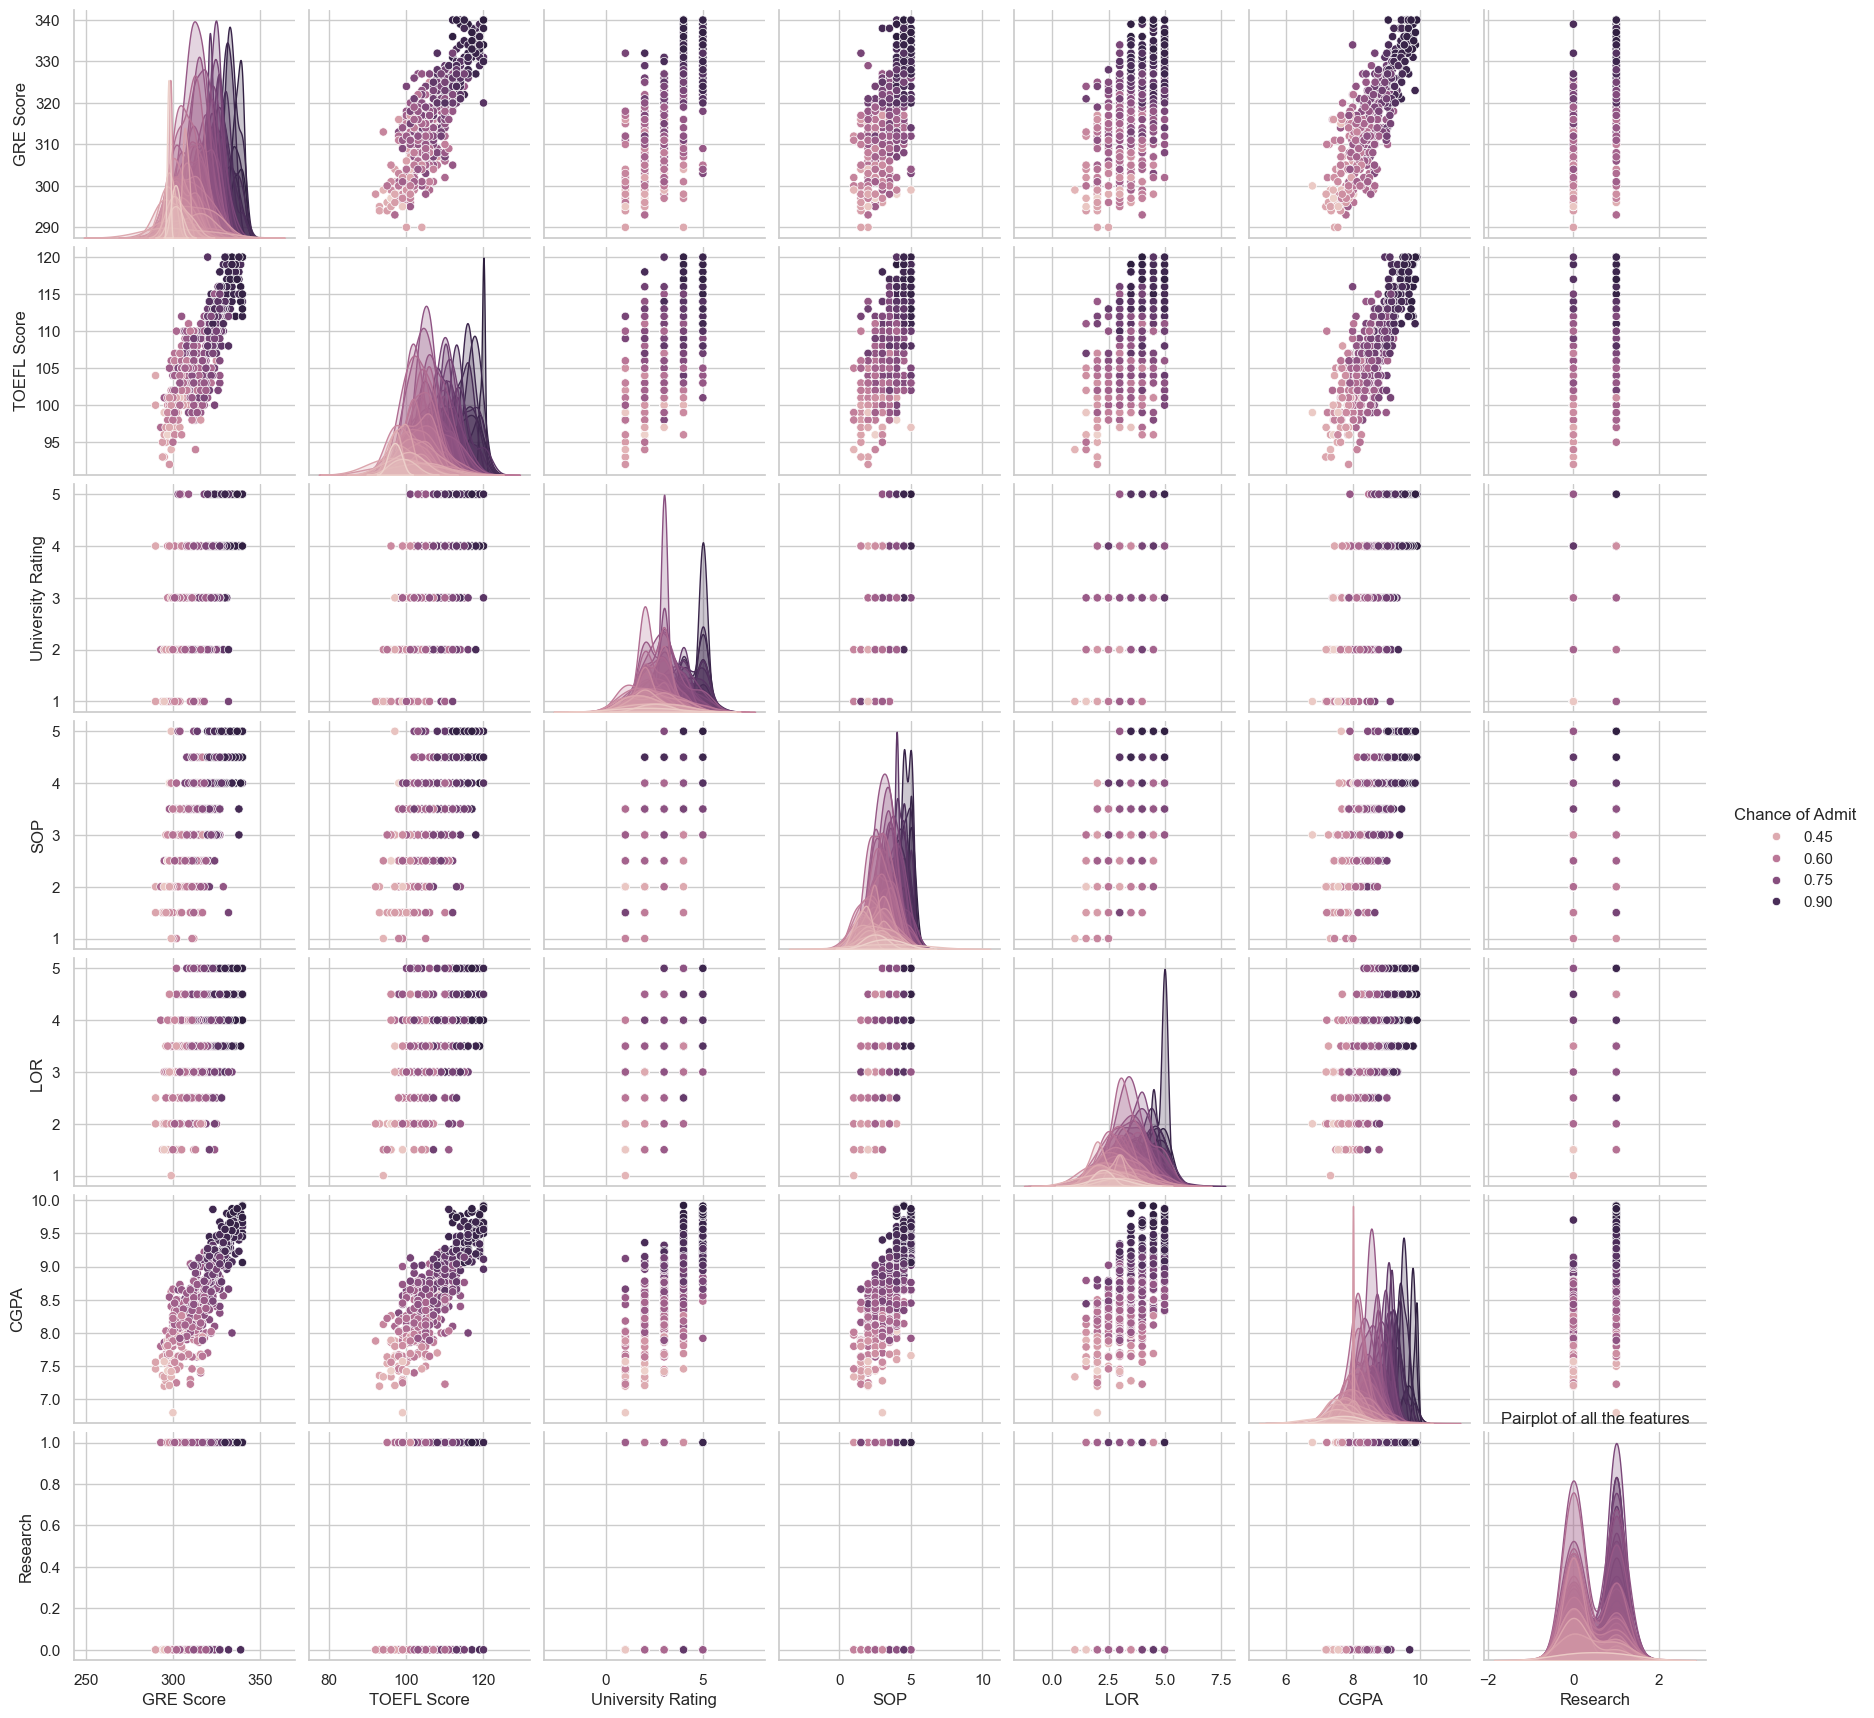

In [15]:
# pair plot of all the numerical columns
plt.figure(figsize = (7, 7))
sns.pairplot(df, hue = "Chance of Admit ")
plt.title("Pairplot of all the features")
plt.savefig("../artifacts/pair_plots_of_all_columns.png")
plt.show()

In [16]:
# data preprocessing

In [17]:
# missing values
df.isna().sum()

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [18]:
# duplicates
df.duplicated().sum()

0

In [19]:
# outliers detection using IQR analysis
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1

# set the threshold (k = 1.5)
k = 1.5
lower_bound = q1 - k * iqr
upper_bound = q3 + k * iqr

# potential outliers
outliers = ((df < lower_bound) | (df > upper_bound)).any(axis = 1)

In [20]:
# outliers treatment
print(df.shape)
df = df[~outliers]
print(df.shape)

(500, 8)
(497, 8)


In [21]:
# renaming the columns
df.rename(columns = {
    "GRE Score": "gre_score",
    "TOEFL Score": "toefl_score",
    "University Rating": "university_rating",
    "SOP": "sop",
    "LOR ": "lor",
    "CGPA": "cgpa",
    "Research": "research",
    "Chance of Admit ": "chance_of_admit",
    "Total Score": "total_score"
}, inplace = True)
df.head()

,gre_score,toefl_score,university_rating,sop,lor,cgpa,research,chance_of_admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [22]:
# saving the cleaned data
df.to_csv("../data/data_cleaned.csv")